# trying to understand the datastructure

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import jupyter_black

from utils import * # import all functions from utils.py

jupyter_black.load() # for cell formatting in jupyter notebooks

In [2]:
# load the data

data = load_data()
print_info(data)

matched cells: 47
templates: ['locally_sparse_noise', 'natural_scenes']

session A (three_session_A)
  t: (115471,), dff: (47, 115471), roi_masks: (47, 512, 512)
  stim 'drifting_gratings': (628, 5) cols=['temporal_frequency', 'orientation', 'blank_sweep', 'start', 'end']

session B (three_session_B)
  t: (113850,), dff: (47, 113850), roi_masks: (47, 512, 512)
  stim 'natural_scenes': (5950, 3) cols=['frame', 'start', 'end']
  stim 'static_gratings': (6000, 5) cols=['orientation', 'spatial_frequency', 'phase', 'start', 'end']

session C (three_session_C)
  t: (105738,), dff: (47, 105738), roi_masks: (47, 512, 512)
  stim 'locally_sparse_noise': (8880, 3) cols=['frame', 'start', 'end']


keys in data: ['matched_cell_ids', 'templates', 'sessions']
keys in templates: ['locally_sparse_noise', 'natural_scenes']
shape of locally_sparse_noise: (9000, 16, 28) (n_frames, height, width)
shape of natural_scenes: (118, 918, 1174) (n_frames, height, width)


(<Figure size 1200x600 with 2 Axes>,
 <Axes: title={'center': 'First Frame of Natural Scenes Stimulus'}>)

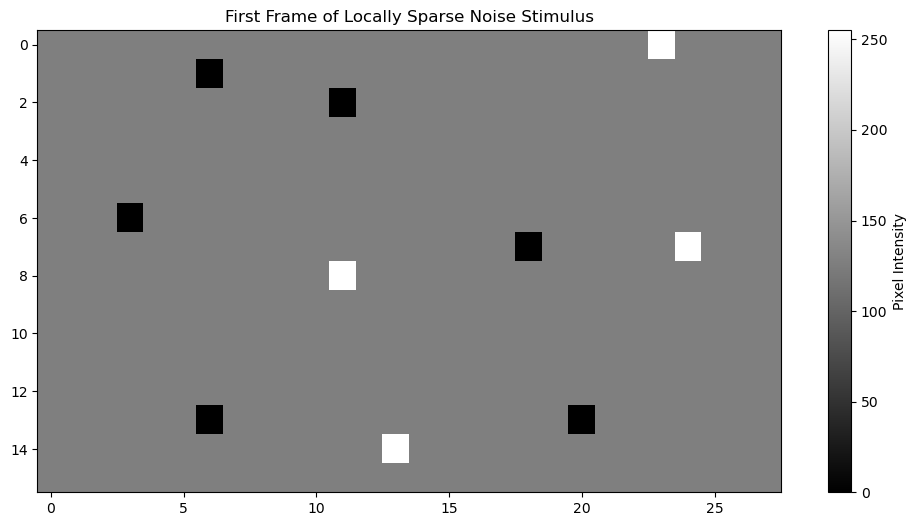

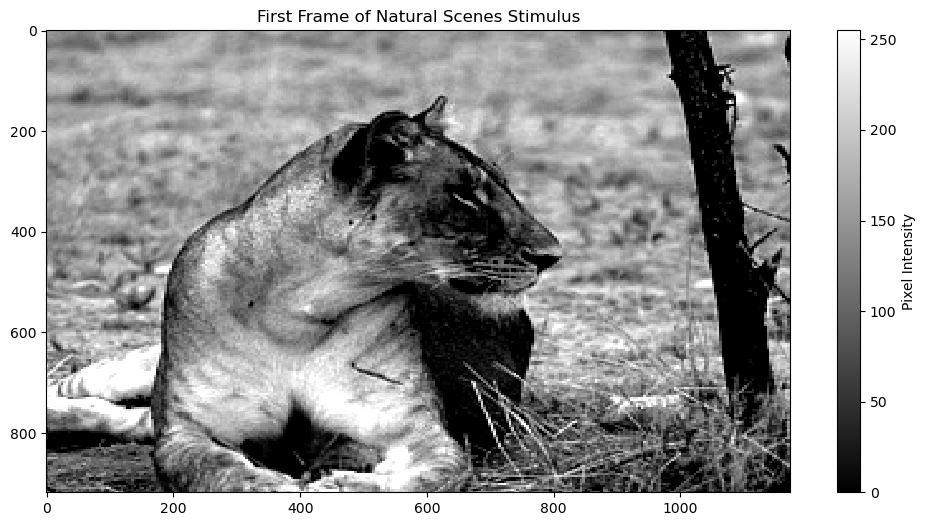

In [4]:
# data
print(f"keys in data: {list(data.keys())}")

##data
templates = data["templates"]  # we only have data for one cell
print("keys in templates:", list(templates.keys()))

### locally_sparse_noise
locally_sparse_noise = templates["locally_sparse_noise"]
print(
    f"shape of locally_sparse_noise: {locally_sparse_noise.shape} (n_frames, height, width)"
)
first_frame_noise = locally_sparse_noise[1, :, :]

### natural_scenes
natural_scenes = templates["natural_scenes"]
print(f"shape of natural_scenes: {natural_scenes.shape} (n_frames, height, width)")
first_frame_natural = natural_scenes[6, :, :]

visualize_matrix(
    first_frame_noise,
    title="First Frame of Locally Sparse Noise Stimulus",
    cmap="gray",
    clabel="Pixel Intensity",
)

visualize_matrix(
    first_frame_natural,
    title="First Frame of Natural Scenes Stimulus",
    cmap="gray",
    clabel="Pixel Intensity",
)

keys in sessions: ['C', 'B', 'A']
keys in Session_A: ['stim_tables', 'session_type', 't', 'dff', 'roi_masks', 'max_projection', 'running_speed', 'stim_epoch_table']


keys in stim_tables: ['drifting_gratings']
   temporal_frequency  orientation  blank_sweep   start     end
0                 1.0        225.0          0.0   747.0   807.0
1                 2.0        180.0          0.0   837.0   897.0
2                 4.0         90.0          0.0   927.0   987.0
3                 1.0        270.0          0.0  1018.0  1077.0
4                 4.0        135.0          0.0  1108.0  1168.0
shape of Session_A_drifting_gratings: (628, 5) (n_stimuli, n_features_of_stim)


Session_A session_type: three_session_A (string)


shape of time: (115471,) (n_timepoints,)
shape of running_speed: (2, 115471) (n_timepoints,)
for some reason, running speed has an empty row:
[[    nan     nan     nan     nan     nan]
 [9.67741 9.71067 9.74392 9.77718 9.81043]]


shape of roi_masks: (47, 512, 512) (n_cells

(<Figure size 1200x600 with 2 Axes>,
 <Axes: title={'center': 'ROI Mask for Cell 0'}>)

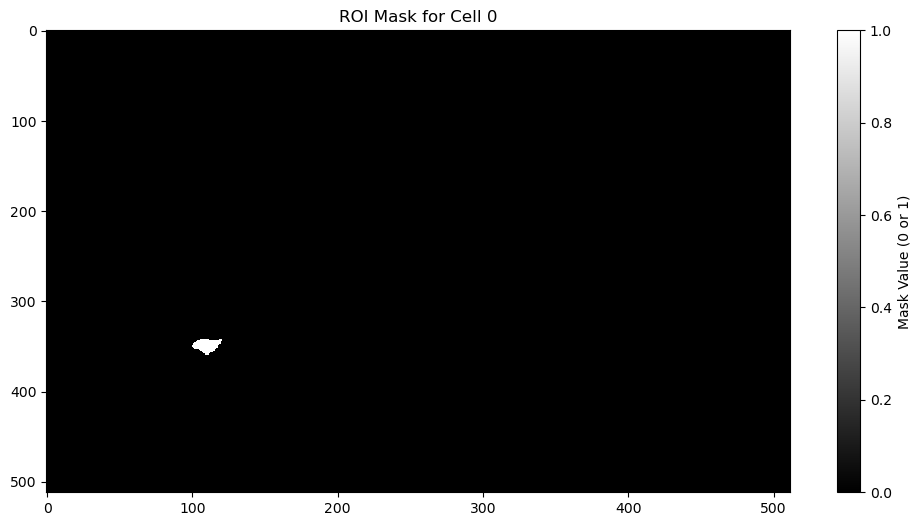

In [5]:
## sessions
sessions = data["sessions"]
print("keys in sessions:", list(sessions.keys()))
Session_A = sessions["A"]
print("keys in Session_A:", list(Session_A.keys()))
print("\n")

#### stim_tables
stim_tables = Session_A["stim_tables"]
print("keys in stim_tables:", list(stim_tables.keys()))
Session_A_drifting_gratings = stim_tables["drifting_gratings"]
print(Session_A_drifting_gratings.head())
print(
    f"shape of Session_A_drifting_gratings: {Session_A_drifting_gratings.shape} (n_stimuli, n_features_of_stim)"
)
print("\n")

### session_types
session_types = Session_A["session_type"]
print(f"Session_A session_type: {session_types} (string)")
print("\n")

### t
time = Session_A["t"]
print(f"shape of time: {time.shape} (n_timepoints,)")

### running speed
running_speed = Session_A["running_speed"]
print(f"shape of running_speed: {running_speed.shape} (n_timepoints,)")
print("for some reason, running speed has an empty row:")
print(running_speed[0:5, 0:5])
print("\n")

### roi_masks
roi_masks = Session_A["roi_masks"]
print(f"shape of roi_masks: {roi_masks.shape} (n_cells, height, width)")
first_cell_mask = roi_masks[0, :, :]
visualize_matrix(
    first_cell_mask,
    title="ROI Mask for Cell 0",
    cmap="gray",
    clabel="Mask Value (0 or 1)",
)

In [6]:
### stim_epoch_table
stim_epoch_table = Session_A["stim_epoch_table"]
stim_epoch_table.head()

,stimulus,start,end
0,drifting_gratings,747,18775
1,natural_movie_three,19709,37767
2,natural_movie_one,38671,47699
3,drifting_gratings,48602,66630
4,spontaneous,66780,75697


shape of max_projection: (512, 512) (height, width)


(<Figure size 1200x600 with 2 Axes>,
 <Axes: title={'center': 'Maximum Intensity Projection of 2-Photon Recording'}>)

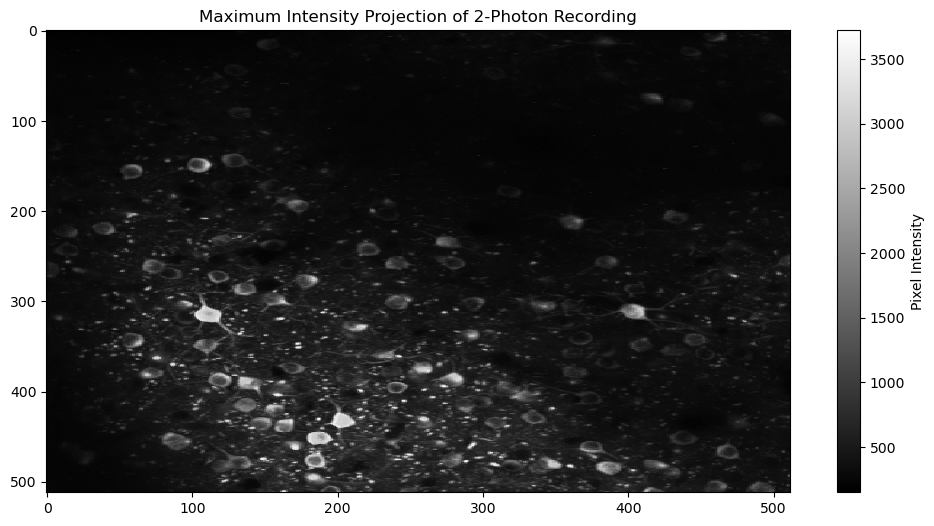

In [7]:
### max projection
max_projection = Session_A["max_projection"]
print(f"shape of max_projection: {max_projection.shape} (height, width)")
visualize_matrix(
    max_projection,
    title="Maximum Intensity Projection of 2-Photon Recording",
    cmap="gray",
    clabel="Pixel Intensity",
)

# 2-Photon Dataset Architecture Overview (by Gemini after pasting above code and outputs)

The `data` object is a nested dictionary separating global stimulus templates from individual recording sessions. 

```text
data/
├── matched_cell_ids/        many cell ids, BUT only the first cell id has data
│
├── templates/               
│   ├── locally_sparse_noise : ndarray (9000, 16, 28)   -> (n_frames, height, width)
│   └── natural_scenes       : ndarray (118, 918, 1174) -> (n_frames, height, width)
│
└── sessions/
    ├── B/                   (Structure likely mirrors Session A)
    ├── C/                   (Structure likely mirrors Session A)
    └── A/
        ├── session_type     : string ("three_session_A")
        │
        ├── Imaging & ROIs
        │   ├── max_projection : ndarray (512, 512)     -> (height, width)
        │   ├── roi_masks      : ndarray (47, 512, 512) -> (n_cells, height, width)
        │   └── dff            : ndarray (Likely (47, 115471) -> (n_cells, n_timepoints))
        │
        ├── Time Series & Behavior
        │   ├── t (time)       : ndarray (115471,)      -> (n_timepoints,)
        │   └── running_speed  : ndarray (2, 115471)    -> (2, n_timepoints)
        │                        *WARNING: Row 0 contains NaNs. Actual speed is in Row 1.
        │
        └── Stimulus Alignments
            ├── stim_epoch_table : DataFrame (Tracks macro stimulus blocks [says the AI, idk])
            │                      Columns: [stimulus_name, start_frame, end_frame]
            │
            └── stim_tables/     (Granular trial-by-trial parameters)
                └── drifting_gratings : DataFrame (628, 5) -> (n_stimuli, n_features)
                                        Features: [temporal_frequency, orientation, 
                                                   blank_sweep, start, end]

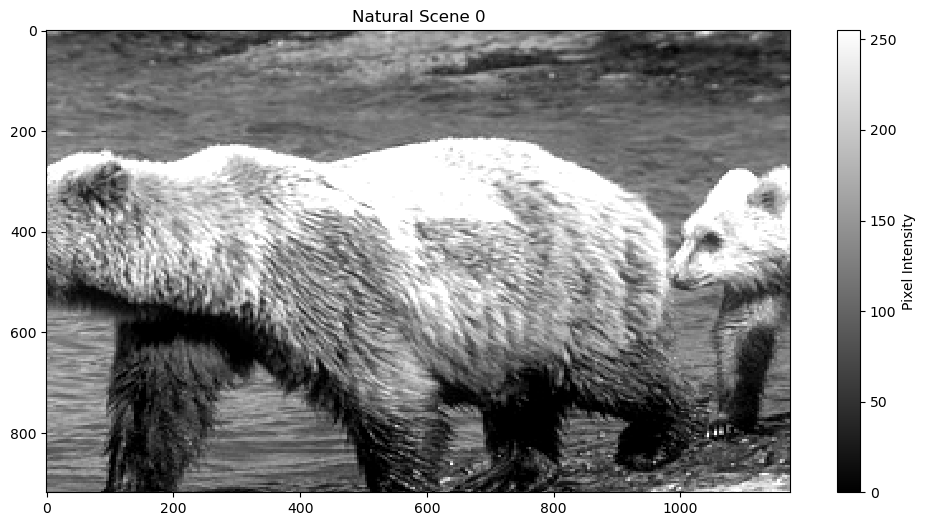

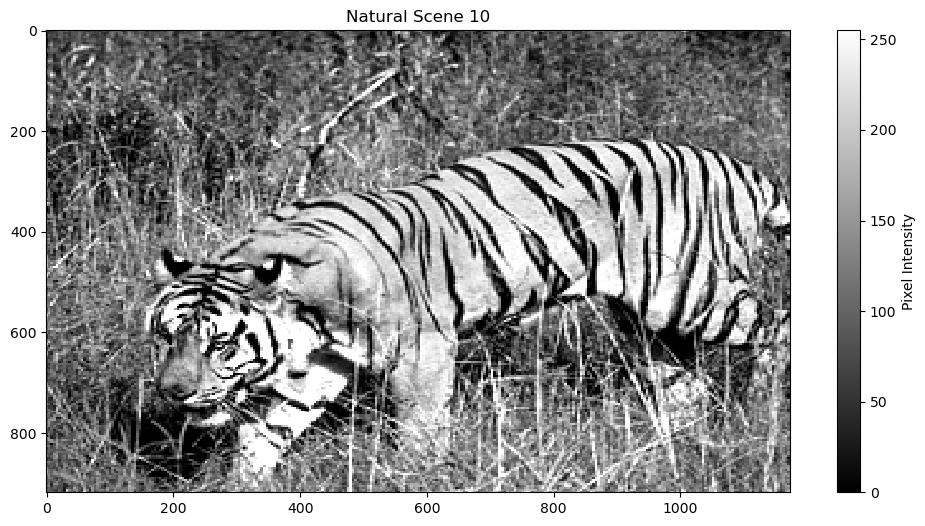

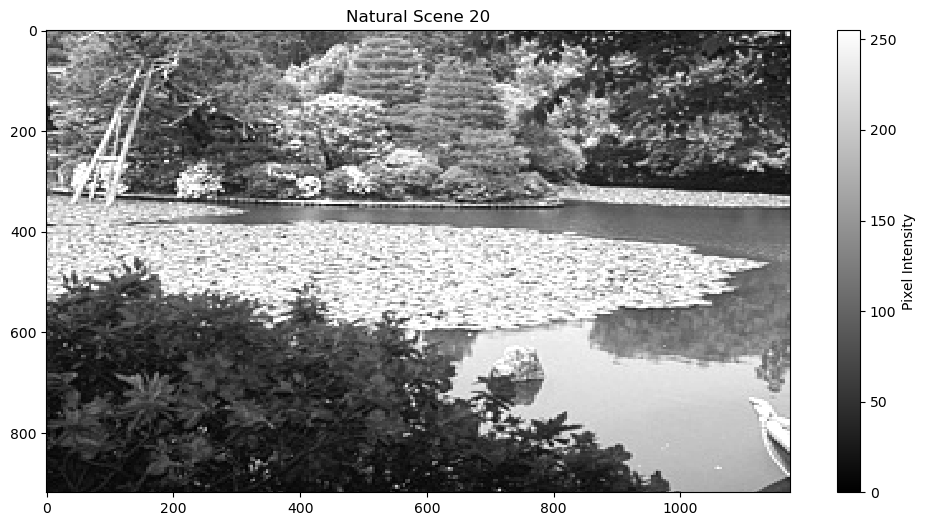

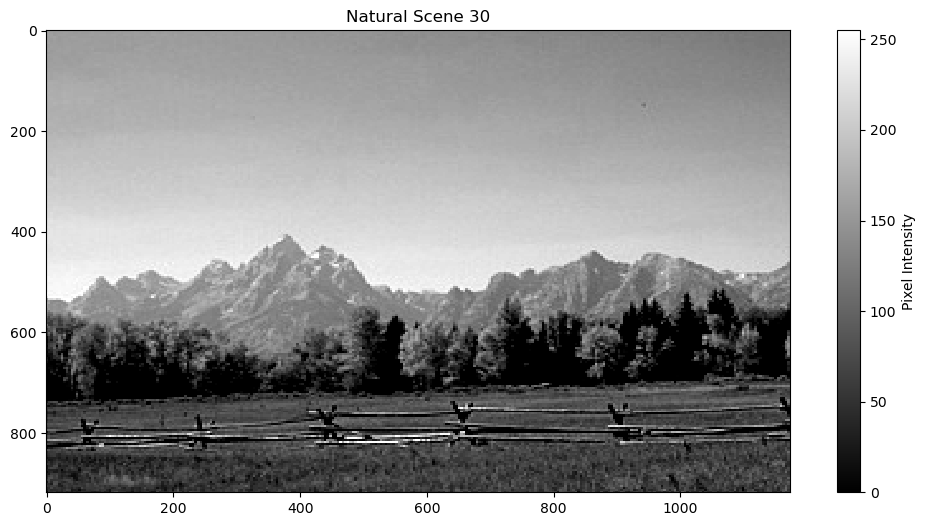

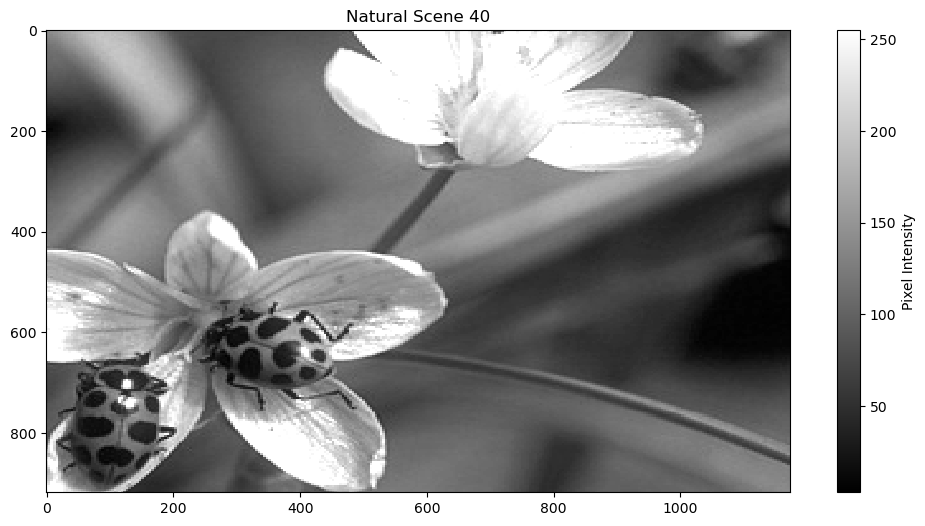

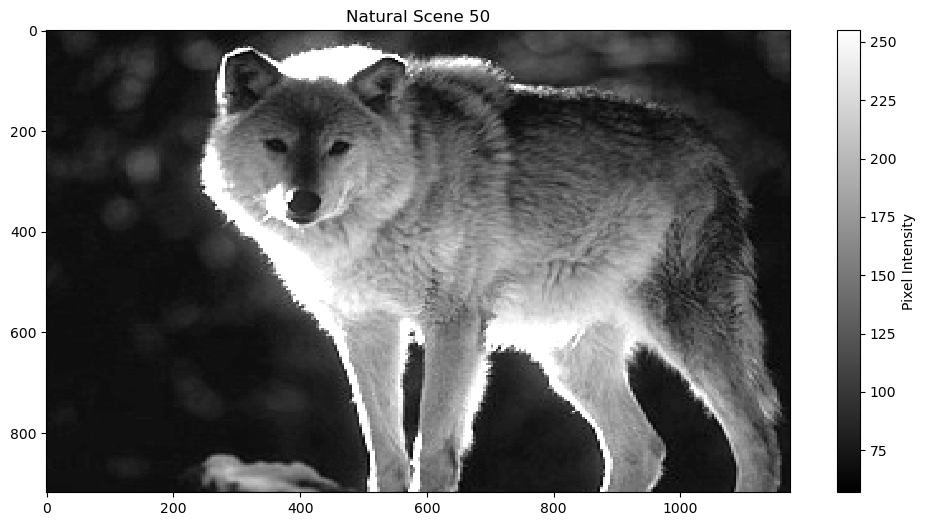

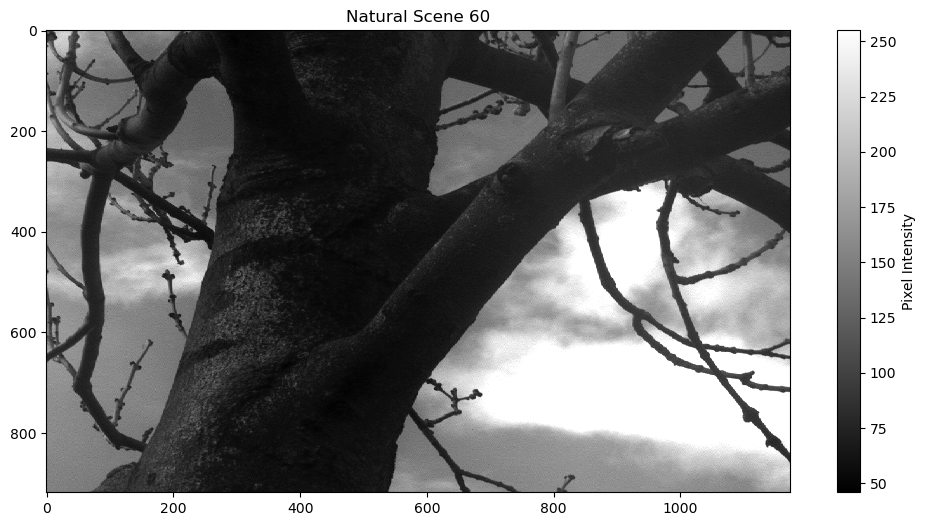

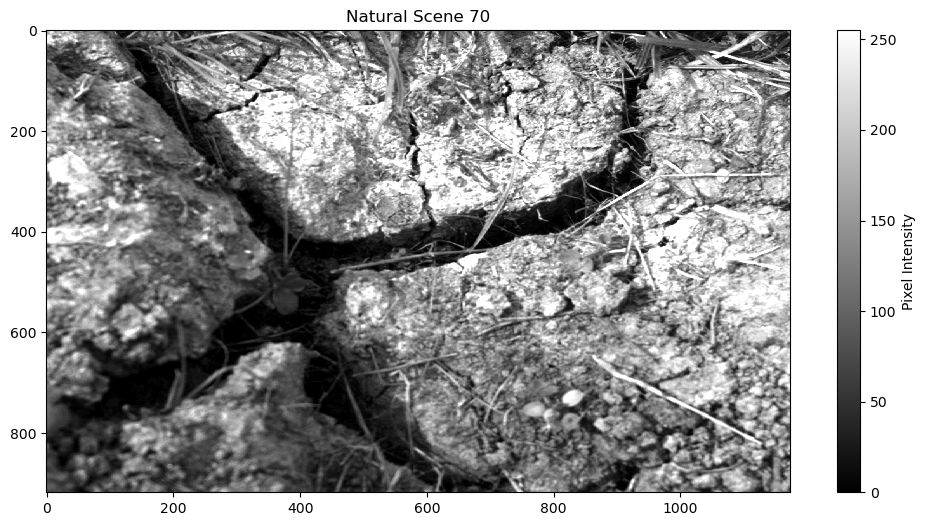

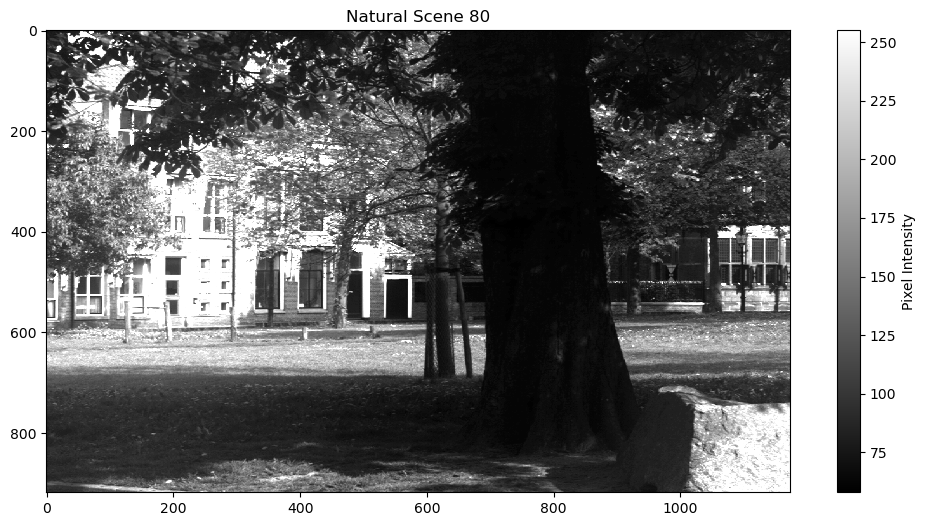

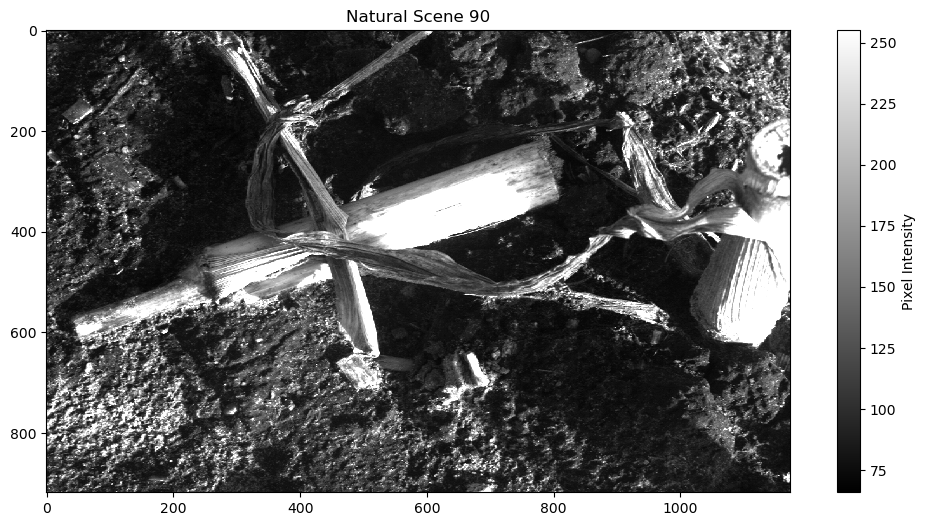

In [9]:
for natural_scene in range(0, 100, 10):
    visualize_matrix(
        natural_scenes[natural_scene, :, :],
        title=f"Natural Scene {natural_scene}",
        cmap="gray",
        clabel="Pixel Intensity",
    )